In [54]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.preprocessing import image

In [55]:
import os

# Ganti dengan username dan key dari akun Kaggle kamu sendiri
os.environ['KAGGLE_USERNAME'] = "gunafatala"
os.environ['KAGGLE_KEY'] = "KGAT_59792fb1e928dde5aba2600bf76497b3"

print("✅ Kredensial Kaggle berhasil dipasang!")

✅ Kredensial Kaggle berhasil dipasang!


In [56]:
import os

# 1. Mengunduh dataset dari Kaggle (garbage-classification tetap)
!kaggle datasets download -d mostafaabla/garbage-classification

# 2. Mengklon dataset dari GitHub (untuk data daur ulang)
# Hapus folder jika sudah ada untuk menghindari error cloning
if os.path.exists('dataset_sampah/Wranglingling'):
    !rm -rf dataset_sampah/Wranglingling
!git clone https://github.com/DBSDicoding2026-UNTIRTA/Wranglingling.git dataset_sampah/Wranglingling

# 3. Mengekstrak file zip secara diam-diam (-q) ke dalam folder 'dataset_sampah'
# Asumsi: garbage-classification.zip mengekstrak ke 'dataset_sampah/garbage_classification'
!unzip -q garbage-classification.zip -d dataset_sampah

print("✅ Dataset berhasil diunduh dan diekstrak!")

Dataset URL: https://www.kaggle.com/datasets/mostafaabla/garbage-classification
License(s): ODbL-1.0
garbage-classification.zip: Skipping, found more recently modified local copy (use --force to force download)
Cloning into 'dataset_sampah/Wranglingling'...
remote: Enumerating objects: 7051, done.
remote: Counting objects: 100% (3/3), done.
remote: Compressing objects: 100% (3/3), done.
remote: Total 7051 (delta 0), reused 0 (delta 0), pack-reused 7048 (from 2)
Receiving objects: 100% (7051/7051), 98.74 MiB | 30.60 MiB/s, done.
Resolving deltas: 100% (24/24), done.
replace dataset_sampah/garbage_classification/battery/battery1.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
✅ Dataset berhasil diunduh dan diekstrak!


In [57]:
base_path_daur_ulang = "dataset_sampah/Wranglingling/clean_images" # Path untuk dataset dari GitHub
base_path_garbage = "dataset_sampah/garbage_classification" # Path untuk dataset garbage-classification
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

In [58]:
def prep_image(file_path, label):
    img = tf.io.read_file(file_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    img = img / 255.0
    return img, label

In [59]:
import random
import os

def get_dataset_path(base_path, target_classes=None, max_images_per_class=None):
    file_paths = []
    labels = []
    actual_class_names = []

    if target_classes is None:
        # Mendapatkan semua subdirektori sebagai nama kelas jika target_classes adalah None
        target_classes_to_process = [d for d in os.listdir(base_path) if os.path.isdir(os.path.join(base_path, d))]
        target_classes_to_process.sort() # Pastikan urutan konsisten
    else:
        target_classes_to_process = target_classes

    for i, class_name in enumerate(target_classes_to_process):
        class_dir = os.path.join(base_path, class_name)
        if os.path.exists(class_dir):
            actual_class_names.append(class_name)
            current_class_files = []
            for file_name in os.listdir(class_dir):
                if file_name.lower().endswith(('.jpg', '.jpeg', '.png')):
                    current_class_files.append(os.path.join(class_dir, file_name))

            # Terapkan max_images_per_class jika ditentukan
            if max_images_per_class is not None and len(current_class_files) > max_images_per_class:
                current_class_files = random.sample(current_class_files, max_images_per_class)

            for file_path in current_class_files:
                file_paths.append(file_path)
                labels.append(len(actual_class_names) - 1) # Label lokal untuk panggilan fungsi ini
        else:
            print(f"Warning: Class directory for '{class_name}' not found at {class_dir}")

    return file_paths, labels, actual_class_names

In [97]:
# --- Memproses dataset 1: sampah-daur-ulang (semua kelas) ---
file_paths_daur_ulang, labels_daur_ulang, class_names_daur_ulang = get_dataset_path(
    base_path_daur_ulang,
    target_classes=None # Ambil semua kelas
)

# --- Memproses dataset 2: garbage-classification (biological, clothes, dengan penyeimbangan) ---
file_paths_garbage, labels_garbage, class_names_garbage = get_dataset_path(
    base_path_garbage,
    target_classes=['biological', 'clothes'],
    max_images_per_class=1200 # Seimbangkan 'clothes'
)

# --- Menggabungkan hasil ---
# Pastikan label dari dataset kedua diimbangi dengan benar
label_offset = len(class_names_daur_ulang)
labels_garbage_offset = [label + label_offset for label in labels_garbage]

file_paths = file_paths_daur_ulang + file_paths_garbage
labels = labels_daur_ulang + labels_garbage_offset
class_names = class_names_daur_ulang + class_names_garbage # class_names global untuk dataset gabungan

print(f"Ditemukan {len(file_paths_daur_ulang)} gambar dari dataset 'sampah-daur-ulang' di {len(class_names_daur_ulang)} kelas: {class_names_daur_ulang}")
print(f"Ditemukan {len(file_paths_garbage)} gambar dari dataset 'garbage-classification' di {len(class_names_garbage)} kelas: {class_names_garbage}")
print(f"Total ditemukan {len(file_paths)} gambar di {len(class_names)} kelas gabungan: {class_names}.")


Ditemukan 7014 gambar dari dataset 'sampah-daur-ulang' di 6 kelas: ['Kaca', 'Kardus', 'Kertas', 'Logam', 'Plastik', 'Residu']
Ditemukan 2185 gambar dari dataset 'garbage-classification' di 2 kelas: ['biological', 'clothes']
Total ditemukan 9199 gambar di 8 kelas gabungan: ['Kaca', 'Kardus', 'Kertas', 'Logam', 'Plastik', 'Residu', 'biological', 'clothes'].


In [61]:
import os

# List contents of the base_path_garbage to check actual folder names
print(f"Contents of '{base_path_garbage}':")
if os.path.exists(base_path_garbage):
    for item in os.listdir(base_path_garbage):
        if os.path.isdir(os.path.join(base_path_garbage, item)):
            print(f"- {item}")
else:
    print(f"Warning: Base path '{base_path_garbage}' does not exist.")

Contents of 'dataset_sampah/garbage_classification':
- green-glass
- trash
- white-glass
- brown-glass
- biological
- cardboard
- plastic
- paper
- metal
- shoes
- clothes
- battery


In [62]:
import os

# List contents of the base_path_daur_ulang to check actual folder names
print(f"Contents of '{base_path_daur_ulang}':")
if os.path.exists(base_path_daur_ulang):
    for item in os.listdir(base_path_daur_ulang):
        if os.path.isdir(os.path.join(base_path_daur_ulang, item)):
            print(f"- {item}")
else:
    print(f"Warning: Base path '{base_path_daur_ulang}' does not exist.")

Contents of 'dataset_sampah/Wranglingling/clean_images':
- Kertas
- Logam
- Plastik
- Kaca
- Kardus
- Residu


In [63]:
import os

# List contents of the top-level extracted directory
print(f"Contents of 'dataset_sampah':")
if os.path.exists('dataset_sampah'):
    for item in os.listdir('dataset_sampah'):
        print(f"- {item}")
else:
    print(f"Warning: Directory 'dataset_sampah' does not exist.")

Contents of 'dataset_sampah':
- garbage_classification
- Wranglingling


In [64]:
train_paths, test_paths, train_labels, test_labels = train_test_split(
    file_paths, labels, test_size=0.2, random_state=42, stratify=labels
)
val_paths, test_paths, val_labels, test_labels = train_test_split(
    test_paths, test_labels, test_size=0.5, random_state=42, stratify=test_labels
)

In [65]:
def create_dataset(file_paths, labels):
    dataset = tf.data.Dataset.from_tensor_slices((file_paths, labels))
    dataset = dataset.map(prep_image, num_parallel_calls = tf.data.AUTOTUNE)
    dataset = dataset.shuffle(buffer_size = 1000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

    return dataset

In [66]:
train_dataset = create_dataset(train_paths, train_labels)
test_dataset = create_dataset(test_paths, test_labels)
val_dataset = create_dataset(val_paths, val_labels)

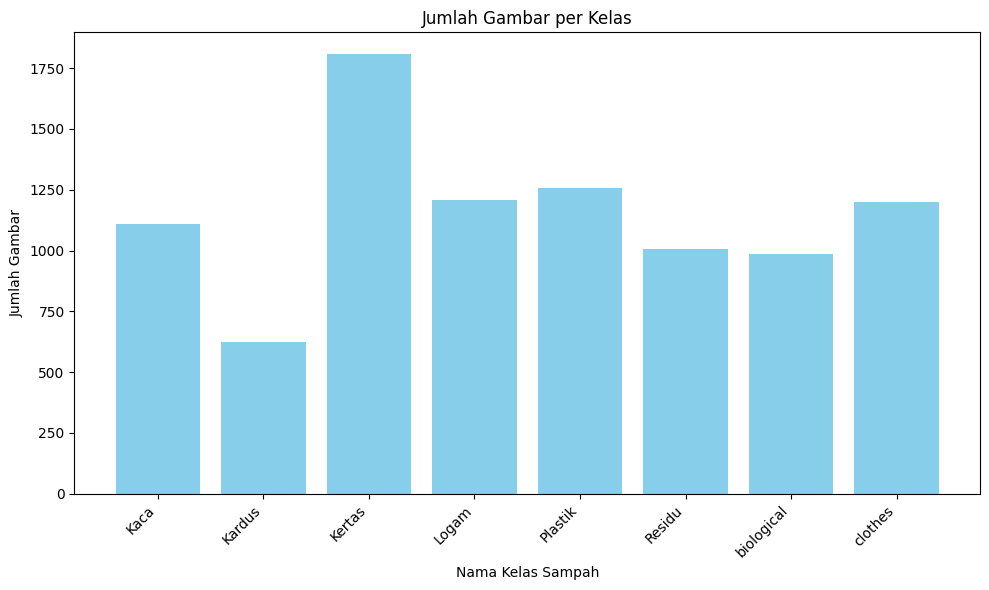

In [67]:
import matplotlib.pyplot as plt
import collections

# Menghitung jumlah gambar per kelas
class_counts = collections.Counter(labels)
sorted_class_counts = dict(sorted(class_counts.items()))

# Mengonversi label numerik ke nama kelas
class_names_for_plot = [class_names[k] for k in sorted_class_counts.keys()]
counts = list(sorted_class_counts.values())

plt.figure(figsize=(10, 6))
plt.bar(class_names_for_plot, counts, color='skyblue')
plt.xlabel('Nama Kelas Sampah')
plt.ylabel('Jumlah Gambar')
plt.title('Jumlah Gambar per Kelas')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [68]:
def augment_image(img, label):
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_brightness(img, max_delta=0.3)
    img = tf.image.random_contrast(img, lower=0.6, upper=1.4)
    img = tf.image.random_saturation(img, lower=0.6, upper=1.4)
    img = tf.image.random_hue(img, max_delta=0.1)
    return img, label


In [69]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, Input
from tensorflow.keras.models import Model

def build_model(num_classes):
    # 1. Definisikan Input secara eksplisit (Wajib di Functional API)
    inputs = Input(shape=IMG_SIZE + (3,))

    # 2. Inisialisasi Base Model
    base_model = MobileNetV2(include_top=False, weights='imagenet', input_shape=IMG_SIZE + (3,))
    base_model.trainable = True  # Fine-tune seluruh layer (sudah benar)

    # 3. Sambungkan layer seperti rantai fungsi
    x = base_model(inputs)
    x = GlobalAveragePooling2D()(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.5)(x)
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.5)(x)

    # 4. Output Layer
    outputs = Dense(num_classes, activation='softmax')(x)

    # 5. Bungkus menjadi tf.keras.Model
    model = Model(inputs=inputs, outputs=outputs)

    return model

# Nanti saat dipanggil, pastikan num_classes = 5 (sesuai batasan proyek)
# num_classes = len(class_names)
# model = build_model(num_classes)

In [70]:
num_classes = len(class_names)
model = build_model(num_classes)
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 8)              │         1,032 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,619,848 (9.99 MB)

 Trainable params: 2,585,736 (9.86 MB)

 Non-trainable params: 34,112 (133.25 KB)

In [71]:
import tensorflow as tf

# 1. Definisikan Komponen Kustom Lanjutan (Memenuhi Main Quest)
class TargetCallback(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        # Mengambil nilai metrik dari log training
        acc = logs.get('accuracy')
        mae = logs.get('mae')

        # Keamanan ganda memastikan metrik tidak kosong
        if acc is not None and mae is not None:
            if acc >= 0.85 and mae <= 0.02:
                print(f"\n✅ Target MBKM Tercapai! Akurasi: {acc*100:.2f}%, MAE: {mae:.4f}")
                print("Misi Selesai. Menghentikan proses training agar tidak overfitting...")
                self.model.stop_training = True

# 2. Inisialisasi callback kustom
custom_target_stop = TargetCallback()

# 3. Gabungkan callback temanmu dengan callback kustom ini
early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3)

# Ini yang nanti akan dipanggil di dalam model.fit()
callbacks_list = [early_stop, reduce_lr, custom_target_stop]

In [72]:
import tensorflow as tf

# Membuat custom metrik MAE khusus untuk label sparse
def mae(y_true, y_pred):
    # Mengubah label angka tunggal menjadi matriks one-hot agar selaras dengan tebakan model
    y_true_one_hot = tf.one_hot(tf.cast(y_true, tf.int32), depth=tf.shape(y_pred)[1])
    return tf.reduce_mean(tf.abs(y_true_one_hot - y_pred))

# Compile ulang modelnya
model.compile(optimizer=tf.keras.optimizers.Adam(1e-5),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy', mae]) # Memanggil fungsi mae buatan kita

In [73]:
import numpy as np
from sklearn.utils.class_weight import compute_class_weight
import tensorflow as tf
import os

# 1. Hitung Class Weights (Kode temanmu yang brilian)
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)
class_weights_dict = dict(enumerate(class_weights))

# 2. Persiapan SIDE QUEST: TensorBoard Callback
log_dir = "logs/fit/"
os.makedirs(log_dir, exist_ok=True)
tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=log_dir, histogram_freq=1)

# 3. Gabungkan SEMUA konduktor (bawaan + custom + tensorboard)
final_callbacks = [early_stop, reduce_lr, custom_target_stop, tensorboard_callback]

# 4. Eksekusi Training (Showtime!)
print("Memulai proses training model...")
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=10,
    class_weight=class_weights_dict,
    callbacks=final_callbacks  # <-- Perubahan krusial ada di sini
)

Memulai proses training model...
Epoch 1/10
230/230 ━━━━━━━━━━━━━━━━━━━━ 166s 401ms/step - accuracy: 0.1700 - loss: 2.3278 - mae: 0.2128 - val_accuracy: 0.3728 - val_loss: 1.7853 - val_mae: 0.2040 - learning_rate: 1.0000e-05
Epoch 2/10
230/230 ━━━━━━━━━━━━━━━━━━━━ 34s 143ms/step - accuracy: 0.2778 - loss: 1.8923 - mae: 0.1995 - val_accuracy: 0.6217 - val_loss: 1.4098 - val_mae: 0.1805 - learning_rate: 1.0000e-05
Epoch 3/10
230/230 ━━━━━━━━━━━━━━━━━━━━ 41s 145ms/step - accuracy: 0.4161 - loss: 1.5783 - mae: 0.1806 - val_accuracy: 0.7337 - val_loss: 1.0883 - val_mae: 0.1500 - learning_rate: 1.0000e-05
Epoch 4/10
230/230 ━━━━━━━━━━━━━━━━━━━━ 34s 144ms/step - accuracy: 0.5153 - loss: 1.3416 - mae: 0.1605 - val_accuracy: 0.7837 - val_loss: 0.8445 - val_mae: 0.1213 - learning_rate: 1.0000e-05
Epoch 5/10
230/230 ━━━━━━━━━━━━━━━━━━━━ 33s 135ms/step - accuracy: 0.5980 - loss: 1.1390 - mae: 0.1412 - val_accuracy: 0.8239 - val_loss: 0.6624 - val_mae: 0.0970 - learning_rate: 1.0000e-05
Epoch 6/10


In [74]:
print("Melanjutkan proses training model (Target: Akurasi >= 85%, MAE <= 0.02)...")

# Kita tingkatkan epoch agar model punya cukup waktu mencapai target Side Quest
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=50, # <-- Dinaikkan menjadi 50
    class_weight=class_weights_dict,
    callbacks=final_callbacks
)

Melanjutkan proses training model (Target: Akurasi >= 85%, MAE <= 0.02)...
Epoch 1/50
230/230 ━━━━━━━━━━━━━━━━━━━━ 33s 139ms/step - accuracy: 0.8281 - loss: 0.5428 - mae: 0.0707 - val_accuracy: 0.9043 - val_loss: 0.3019 - val_mae: 0.0401 - learning_rate: 1.0000e-05
Epoch 2/50
230/230 ━━━━━━━━━━━━━━━━━━━━ 33s 140ms/step - accuracy: 0.8399 - loss: 0.5047 - mae: 0.0652 - val_accuracy: 0.9109 - val_loss: 0.2853 - val_mae: 0.0374 - learning_rate: 1.0000e-05
Epoch 3/50
230/230 ━━━━━━━━━━━━━━━━━━━━ 33s 137ms/step - accuracy: 0.8519 - loss: 0.4640 - mae: 0.0594 - val_accuracy: 0.9174 - val_loss: 0.2674 - val_mae: 0.0341 - learning_rate: 1.0000e-05
Epoch 4/50
230/230 ━━━━━━━━━━━━━━━━━━━━ 34s 145ms/step - accuracy: 0.8596 - loss: 0.4279 - mae: 0.0560 - val_accuracy: 0.9261 - val_loss: 0.2531 - val_mae: 0.0321 - learning_rate: 1.0000e-05
Epoch 5/50
230/230 ━━━━━━━━━━━━━━━━━━━━ 40s 138ms/step - accuracy: 0.8727 - loss: 0.3907 - mae: 0.0512 - val_accuracy: 0.9293 - val_loss: 0.2425 - val_mae: 0.029

In [88]:
import tensorflow as tf

# Re-define TargetCallback to correctly monitor validation metrics
class TargetCallback(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        val_acc = logs.get('val_accuracy')
        val_mae = logs.get('val_mae')

        # Target: val_accuracy >= 0.85 and val_mae <= 0.02
        if val_acc is not None and val_mae is not None:
            if val_acc >= 0.85 and val_mae <= 0.02:
                print(f"\n✅ Target MBKM Tercapai! Val Akurasi: {val_acc*100:.2f}%, Val MAE: {val_mae:.4f}")
                print("Misi Selesai. Menghentikan proses training agar tidak overfitting...")
                self.model.stop_training = True

# Re-instantiate custom_target_stop with the updated class definition
custom_target_stop = TargetCallback()

# Re-compile the model with a fresh, even lower learning rate for fine-tuning
# This also resets the optimizer's state.
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-6), # Lower learning rate
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy', mae]) # 'mae' is still our custom metric

# Rebuild final_callbacks list, using the existing early_stop and reduce_lr
# and the newly instantiated custom_target_stop
final_callbacks = [early_stop, reduce_lr, custom_target_stop, tensorboard_callback]

print("Melanjutkan proses training model dengan Target: Val Akurasi >= 85%, Val MAE <= 0.02 (dengan learning rate lebih rendah)...")

# Continue training for up to 10 epochs
history_continued = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=10, # Max 10 epochs as requested
    class_weight=class_weights_dict,
    callbacks=final_callbacks
)

# Evaluate the model again on the test set after this round of training
# (Note: test_mae is only checked once after training, not for early stopping during training)
test_loss_continued, test_accuracy_continued, test_mae_continued = model.evaluate(test_dataset)

print(f"\n📊 Hasil Evaluasi Model Setelah Lanjutan Training:")
print(f"Test Accuracy : {test_accuracy_continued * 100:.2f}%")
print(f"Test MAE      : {test_mae_continued:.4f}")

# Update global variables for plotting if needed later
test_accuracy = test_accuracy_continued
test_mae = test_mae_continued

# The 'history' variable from previous training is not directly appended,
# but we can use history_continued for new plots if desired.
# If you wish to plot the full history, you would need to combine history and history_continued manually.

Melanjutkan proses training model dengan Target: Val Akurasi >= 85%, Val MAE <= 0.02 (dengan learning rate lebih rendah)...
Epoch 1/10
230/230 ━━━━━━━━━━━━━━━━━━━━ 0s 234ms/step - accuracy: 0.9511 - loss: 0.1571 - mae: 0.0227
✅ Target MBKM Tercapai! Val Akurasi: 94.24%, Val MAE: 0.0184
Misi Selesai. Menghentikan proses training agar tidak overfitting...
230/230 ━━━━━━━━━━━━━━━━━━━━ 123s 294ms/step - accuracy: 0.9481 - loss: 0.1647 - mae: 0.0231 - val_accuracy: 0.9424 - val_loss: 0.1953 - val_mae: 0.0184 - learning_rate: 1.0000e-06
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.9174 - loss: 0.2925 - mae: 0.0257

📊 Hasil Evaluasi Model Setelah Lanjutan Training:
Test Accuracy : 91.74%
Test MAE      : 0.0257


In [89]:
# Tambahkan test_mae untuk menampung output ketiga
test_loss, test_accuracy, test_mae = model.evaluate(test_dataset)

print(f"📊 Hasil Ujian Akhir Model:")
print(f"Test Accuracy : {test_accuracy * 100:.2f}%")
print(f"Test MAE      : {test_mae:.4f}")

29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.9174 - loss: 0.2925 - mae: 0.0255
📊 Hasil Ujian Akhir Model:
Test Accuracy : 91.74%
Test MAE      : 0.0255


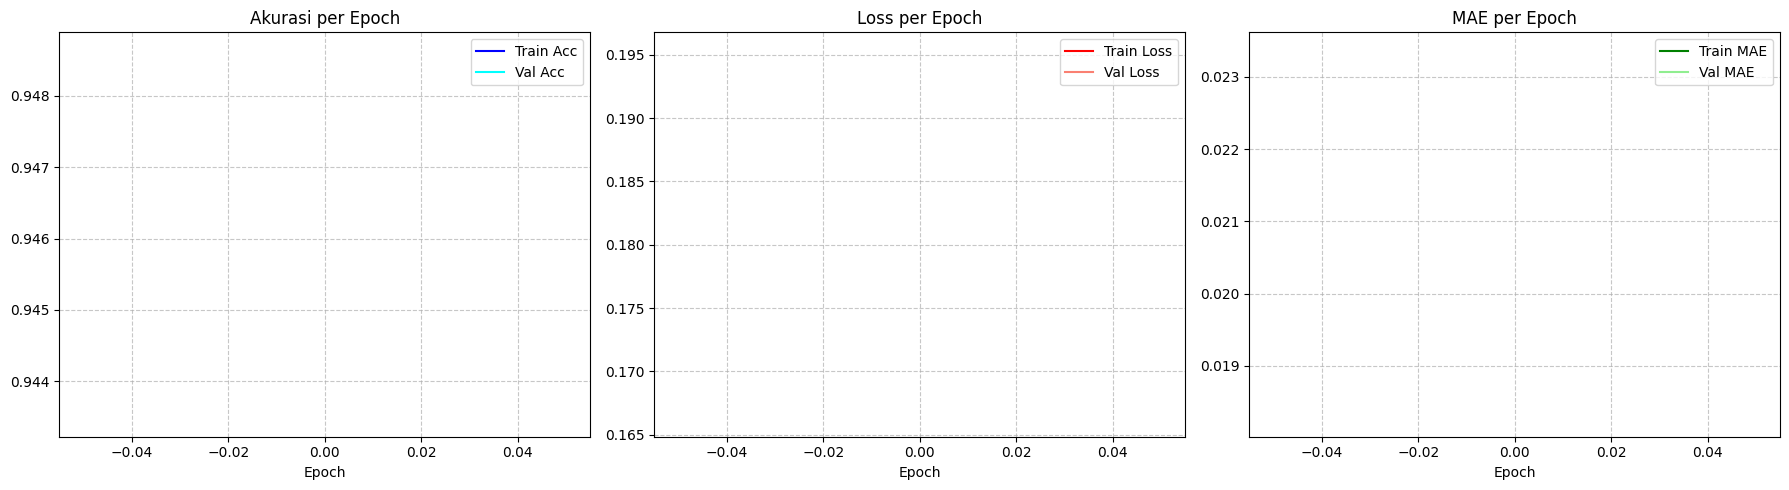

In [92]:
import matplotlib.pyplot as plt

# Membuat kanvas yang lebar untuk 3 grafik
plt.figure(figsize=(18, 5))

# 1. Grafik Akurasi
plt.subplot(1, 3, 1)
plt.plot(history.history['accuracy'], label='Train Acc', color='blue')
plt.plot(history.history['val_accuracy'], label='Val Acc', color='cyan')
plt.legend()
plt.title('Akurasi per Epoch')
plt.xlabel('Epoch')
plt.grid(True, linestyle='--', alpha=0.7)

# 2. Grafik Loss
plt.subplot(1, 3, 2)
plt.plot(history.history['loss'], label='Train Loss', color='red')
plt.plot(history.history['val_loss'], label='Val Loss', color='salmon')
plt.legend()
plt.title('Loss per Epoch')
plt.xlabel('Epoch')
plt.grid(True, linestyle='--', alpha=0.7)

# 3. Grafik MAE (Pembuktian Side Quest)
plt.subplot(1, 3, 3)
plt.plot(history.history['mae'], label='Train MAE', color='green')
plt.plot(history.history['val_mae'], label='Val MAE', color='lightgreen')
plt.legend()
plt.title('MAE per Epoch')
plt.xlabel('Epoch')
plt.grid(True, linestyle='--', alpha=0.7)

# Menampilkan semua grafik
plt.tight_layout()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━

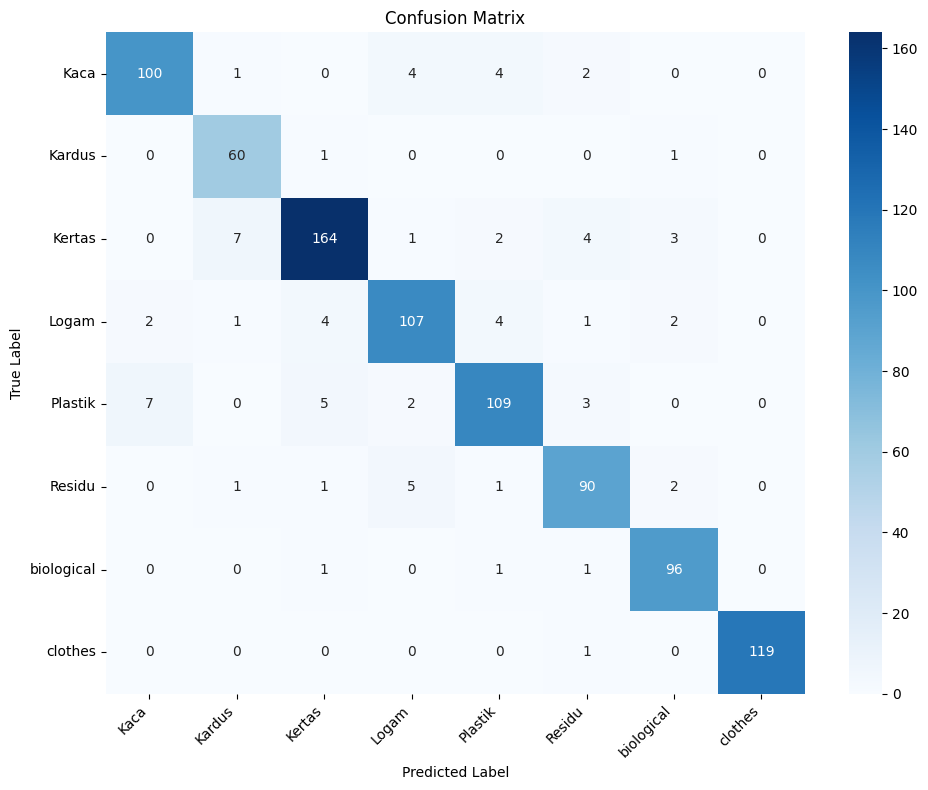

In [99]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. Mengumpulkan prediksi dan label sebenarnya dari test_dataset
y_pred_raw = []
y_true = []

for images, labels in test_dataset:
    preds = model.predict(images)
    y_pred_raw.extend(np.argmax(preds, axis=1))
    y_true.extend(labels.numpy())

y_pred = np.array(y_pred_raw)
y_true = np.array(y_true)

# 2. Menghitung Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

# 3. Visualisasi Confusion Matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


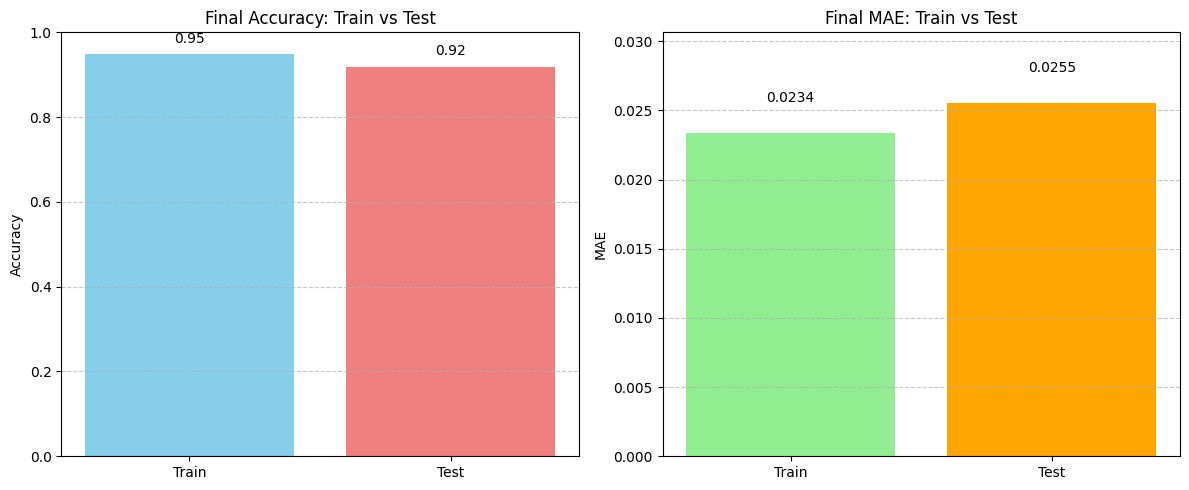

In [86]:
import matplotlib.pyplot as plt

# Get final training metrics from history
final_train_accuracy = history.history['accuracy'][-1]
final_train_mae = history.history['mae'][-1]

# Get test metrics (already available from model.evaluate)
# test_accuracy
# test_mae

labels = ['Train', 'Test']

# Create a figure with two subplots
plt.figure(figsize=(12, 5))

# Bar Chart for Accuracy
plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
accuracy_values = [final_train_accuracy, test_accuracy]
plt.bar(labels, accuracy_values, color=['skyblue', 'lightcoral'])
plt.ylabel('Accuracy')
plt.title('Final Accuracy: Train vs Test')
plt.ylim(0, 1) # Accuracy is between 0 and 1
for i, value in enumerate(accuracy_values):
    plt.text(i, value + 0.02, f'{value:.2f}', ha='center', va='bottom')
plt.grid(axis='y', linestyle='--', alpha=0.7)


# Bar Chart for MAE
plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
mae_values = [final_train_mae, test_mae]
plt.bar(labels, mae_values, color=['lightgreen', 'orange'])
plt.ylabel('MAE')
plt.title('Final MAE: Train vs Test')
plt.ylim(0, max(mae_values) * 1.2) # Adjust y-limit dynamically
for i, value in enumerate(mae_values):
    plt.text(i, value + 0.002, f'{value:.4f}', ha='center', va='bottom')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [77]:
model.save("sampah_classifier.keras")

In [78]:
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import load_model
from google.colab import files
import numpy as np
import matplotlib.pyplot as plt
import os

# --- 1. Parameter dan Setup ---
IMG_SIZE = (224, 224)
# DATASET_PATH tidak lagi digunakan karena class_names diambil dari proses pelatihan gabungan.
UPLOAD_FOLDER = "sampah"
os.makedirs(UPLOAD_FOLDER, exist_ok=True)

# --- 2. Load class_names ---
# class_names = sorted(os.listdir(DATASET_PATH)) # Baris ini dikomentari karena class_names sudah global dari sel data loading
print(f"📚 Daftar kelas yang dikenali: {class_names}")

# --- 3. Load model (DENGAN CUSTOM OBJECT) ---
# Wajib menyertakan custom_objects karena kita memakai metrik kustom 'mae' saat training
model = load_model("sampah_classifier.keras", custom_objects={'mae': mae})
print("✅ Model berhasil dimuat.")

# --- 4. Fungsi prediksi gambar ---
def predict_image(img_path):
    img = image.load_img(img_path, target_size=IMG_SIZE)
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0) / 255.0
    predictions = model.predict(img_array)[0]

    predicted_index = np.argmax(predictions)
    predicted_class = class_names[predicted_index]
    confidence = predictions[predicted_index]

    print("\n🔍 Detail Probabilitas:")
    for i, prob in enumerate(predictions):
        print(f" - {class_names[i]}: {prob*100:.2f}%")

    plt.imshow(img)
    plt.axis('off')
    plt.title(f"Prediksi: {predicted_class} ({confidence*100:.2f}%)")
    plt.show()

    return predicted_class, confidence

# --- 5. Fungsi perhitungan nilai tukar (Sudah diperbaiki hurufnya) ---
def calculate_exchange(sampah_count):
    # Menggunakan lowercase agar cocok 100% dengan class_names dari folder
    harga_sampah = {
        "plastik": 100,
        "kaca": 200,
        "kardus": 500,
        "kertas": 0,
        "logam": 100,
        "residu": 0
    }

    total_value = 0
    detail = []

    for jenis, jumlah in sampah_count.items():
        if jumlah > 0:
            value = harga_sampah.get(jenis.lower(), 0) * jumlah
            detail.append(f"{jumlah} {jenis.capitalize()} x Rp{harga_sampah.get(jenis.lower(), 0)}")
            total_value += value

    detail_str = " + ".join(detail)
    return total_value, detail_str

# --- 6. Proses Input dan Loop Prediksi ---
sampah_count = {jenis: 0 for jenis in class_names}

while True:
    print("\n🔼 Silakan unggah gambar...")
    uploaded = files.upload()

    if not uploaded: # Jika batal unggah
        print("Membatalkan unggahan...")
        break

    for filename in uploaded.keys():
        print(f"\n📷 Memproses gambar: {filename}")
        file_path = os.path.join(UPLOAD_FOLDER, filename)

        with open(file_path, 'wb') as f:
            f.write(uploaded[filename])

        predicted_class, confidence = predict_image(file_path)
        print(f"✅ Hasil: {predicted_class.upper()} ({confidence*100:.2f}%)")

        sampah_count[predicted_class] += 1

    another = input("➕ Apakah ada gambar lain yang ingin dimasukkan? (ya/tidak): ").strip().lower()
    if another != "ya":
        break

# --- 7. Tampilkan Hasil Akhir ---
print("\n==============================")
print("📊 REKAPITULASI PILAHYUK!")
print("==============================")
for jenis, jumlah in sampah_count.items():
    if jumlah > 0:
        print(f" - {jenis.capitalize()}: {jumlah} buah")

total_value, detail_str = calculate_exchange(sampah_count)
print(f"\n💰 Detail Perhitungan : {detail_str}")
print(f"💵 Total Nilai Tukar  : Rp{total_value}")
print("==============================")

📚 Daftar kelas yang dikenali: ['Kaca', 'Kardus', 'Kertas', 'Logam', 'Plastik', 'Residu', 'biological', 'clothes']
✅ Model berhasil dimuat.

🔼 Silakan unggah gambar...


Membatalkan unggahan...

📊 REKAPITULASI PILAHYUK!

💰 Detail Perhitungan : 
💵 Total Nilai Tukar  : Rp0


In [79]:
pip install fastapi uvicorn tensorflow pillow numpy python-multipart

In [98]:
from fastapi import FastAPI, UploadFile, File
from fastapi.middleware.cors import CORSMiddleware
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
import numpy as np
import io
from PIL import Image
import tensorflow as tf

# 1. Inisialisasi Aplikasi
app = FastAPI(title="API PilahYuk!")

# 2. Atur CORS (Sangat krusial untuk Next.js)
app.add_middleware(
    CORSMiddleware,
    allow_origins=["*"], # Mengizinkan request dari web manapun (bisa diubah spesifik ke localhost:3000 nanti)
    allow_credentials=True,
    allow_methods=["*"],
    allow_headers=["*"],
)

# 3. Definisikan ulang custom metric MAE (Wajib ada agar .keras bisa di-load)
def mae(y_true, y_pred):
    y_true_one_hot = tf.one_hot(tf.cast(y_true, tf.int32), depth=tf.shape(y_pred)[1])
    return tf.reduce_mean(tf.abs(y_true_one_hot - y_pred))

# 4. Load Model saat server nyala
print("Memuat model AI PilahYuk!...")
model = load_model("sampah_classifier.keras", custom_objects={'mae': mae})

# Gunakan daftar kelas global yang sudah ada dari proses loading data
# class_names = ['Kaca', 'Kardus', 'Kertas', 'Logam', 'Plastik', 'Residu'] # Baris ini dikomentari/dihapus

@app.get("/")
def read_root():
    return {"pesan": "API PilahYuk! Berjalan Lancar 🚀"}

@app.post("/predict")
async def predict_sampah(file: UploadFile = File(...)):
    try:
        # Baca file gambar yang diupload Next.js
        contents = await file.read()

        # Konversi ke RGB untuk menghindari error gambar PNG ber-alpha channel (transparan)
        img = Image.open(io.BytesIO(contents)).convert("RGB")
        img = img.resize((224, 224))

        # Preprocessing (harus sama persis dengan fungsi prep_image di Colab)
        img_array = image.img_to_array(img)
        img_array = np.expand_dims(img_array, axis=0) / 255.0

        # Eksekusi Prediksi
        predictions = model.predict(img_array)[0]
        predicted_index = np.argmax(predictions)

        # Ambil label dan probabilitas
        label = class_names[predicted_index]
        confidence = float(predictions[predicted_index])

        # Kembalikan response JSON yang rapi untuk dibaca Next.js
        return {
            "status": "success",
            "data": {
                "jenis_sampah": label,
                "confidence": confidence
            }
        }
    except Exception as e:
        return {"status": "error", "message": str(e)}


Memuat model AI PilahYuk!...
